<div dir="rtl"; display="flex"; text-align="right" align="right">

# כריית מידע - ממן 11


<div dir="rtl">
סטודנט: עומר שרייבשטיין
</div>
<div dir="rtl">
ת.ז: 205984271
</div>

</div>

<br><br>
<div dir="rtl">
    
### **שאלה 1**

    ציין והדגים את שלבי הכנת הנתונים לביצוע כריית מידע כדוגמת טיפול בערכים חסרים, ערכים שגויים ועוד. בסיום, בנה בסיס נתונים מטוייב



<br>
<br>
<div dir="rtl">
ככתוב בספר (פרק 2), נתחיל להכיר את בסיס הנתונים, נלמד את התפלגות המידע לפי חתכים שונים, כלומר לפי קטגוריות של כל שדה והתניות שונות, לא יותר מדי מורכבות בשלב הזה. זאת במטרה להתיידד עם הנתונים
לא למהר להסיק מסקנות:

    
*"צריך לתת למידע לדבר"*



<br>
<br>
<div dir="rtl">
 בשלב הראשון, לקחתי את הטבלה המוצגת בממ"ן ויצרתי עותק מתורגם לאנגלית ובפורמט CSV
 <br>
 זהו קובץ data.csv אותו ניתן לטעון ולנתח באמצעות ספריית pandas של python
<br>
את הערכים החסרים שמופיעים בטבלת הממ"ן כ-???? החלפתי ב NaN
<br>
כמתואר למטה, נפתח שני dataframes:

- df הינו העותק המקורי (בתרגום לאנגלית)
- fixed_df הוא עותק שעליו נבצע את השלמות הערכים החסרים ואולי תיקוני שגיאות במידה ונידרש
<br><br>
אגב, NaN פירושו: Not A Number, והוא נחשב לערך הסטנדרנטי שמקובל לתת לערכים חסרים

<br>
<br>
<div dir="rtl">

### הנחות יסוד

1. נניח כי BMI תקין הוא כל ערך גדול או שווה ל-27.5, BMI מעל 27.5 יוגדר כמשקל עודף
2. נניח כי רמת סוכר תקינה היא בין 80 ל-140. כל ערך שאינו בטווח זה יוגדר כרמת סוכר נמוכה או גבוהה מדי
3. נגדיר כי נבדק *בריא* זהו נבדק שאינו סובל מיתר לחץ דם, אינו לוקה בשום מחלה לבבית ואינו לקה בשבץ
4. נניח כי לנבדקים המוגדרים כ*בריאים* נצפה כי הדבר יבוא לידי ביטוי בערכי BMI וסוכר תקינים. כפועל יוצא, נבדק בריא שאחד מערכים אלו אינו משקף זאת ייחשד בכך שערכים אלו שגויים ושיש לתקן אותם.
5. היות ואינני רופא, בהיינתן נבדק שאינו בריא ושורת הנתונים שלו מכילה ערכים אנומליים, סביר כי ערכים אלו הם סיבה או תוצאה למצבם הבריאותי הגרוע - על כן לא נתקן אותם

כל תיקון של ערך חסר או חשוד כשגוי יהיה בהתאמה ל-5 הנחות אלו. נשווה בין נבדקים עם מאפיינים דומים ונתקן על פי עקרון רוב "יחסי", זאת בשונה מרוב כללי של כל קטגוריה
<div dir="rtl">
<br>
בפרק data cleaning (2.4.2) אפשר להתייחס לזה כהשלמה/תיקון של ערכים על פי העקרון השני.
לגבי העקרון השני של השלמה ידנית, לא מדובר בכמות גדולה מדי של נתונים ולכן ניתן להשקיע זמן ומאמץ למצוא את הערכים הטובים ביותר (זה נכון לבית, אולם כנראה שבזמן הבחינה נאלץ להתפשר...)
<div dir="rtl">
<br><br>
תיקון של ערכים נומרים שמייצגים נבדק תקין יהיו הערך הממוצע של BMI (22.25) או Blood_Sugar (110). באופן הזה נקטין את ה bias שתיקון מלאכותי זה עשוי ליצור וכן קל לזהות ערכים אלו כערכים שבסבירות גבוהה התקבלו כתוצאה מתיקון

<br>
<br>
<div dir="rtl">

### הכנת סביבת העבודה
#### טעינה של ספריות python נדרשות, פונקציות עזר, וטעינת data.csv

In [1]:
# load everything we need to perform visual analysis

# need to install if missing
#pip install seaborn
#pip install numpy
#pip install matplotlib
#pip install pandas

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

In [2]:
# all analysis tools functions
def make_histogram(data, feature, bins):
    sns.histplot(data=data[feature], bins=bins, color="teal")
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()
    

def make_xy_scatter_plot(data, x_feature, y_feature):
    df_clean = data[[x_feature, y_feature]].dropna()

    x = df_clean[x_feature]
    y = df_clean[y_feature]

    plt.scatter(x, y, color='blue', label='Data points')

    a, b = np.polyfit(x, y, 1)
    y_est = a * x + b

    plt.plot(x, y_est, color='red', label=f'Fit: y = {a:.2f}x + {b:.2f}')

    plt.xlabel(x_feature)
    plt.ylabel(y_feature)
    plt.title(f'{x_feature} vs {y_feature} with Regression Line')
    plt.legend()
    plt.show()



def analyze_data(conditions, csv_path="data.csv", data=None):
    """
    conditions: dict where keys are column names and values are:
                - a single value (e.g., "Yes")
                - a list of allowed values (e.g., ["61-70", "70+"])
                
    Example:
        analyze_data({"Stroke": "Yes", "Age_Range": ["61-70", "70+"]})
    """

    # Load dataset
    if data is None:
        df = pd.read_csv(csv_path)

    else:
        df = data
        
    # Apply filtering conditions
    filtered = df.copy()
    for col, val in conditions.items():
        if isinstance(val, list):
            filtered = filtered[filtered[col].isin(val)]
        else:
            filtered = filtered[filtered[col] == val]

    if filtered.empty:
        print("No data matches the given conditions.")
        return

    print(f"Filtered dataset size: {len(filtered)} subjects\n")

    # Determine which columns to visualize
    excluded_cols = list(conditions.keys())
    columns_to_plot = [c for c in df.columns if c not in excluded_cols and c != "Subject_ID"]

    # Separate categorical vs numeric
    categorical_cols = [c for c in columns_to_plot if df[c].dtype == "object"]
    numeric_cols = [c for c in columns_to_plot if df[c].dtype != "object"]

    # --- Visualization ---
    sns.set(style="whitegrid")

    # Plot categorical distributions
    for col in categorical_cols:
        plt.figure(figsize=(6,4))
        sns.countplot(data=filtered, x=col, hue=col, palette="viridis", legend=False)
        plt.title(f"Distribution of {col} (after applying conditions)")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()

    # Plot numeric distributions
    # for col in numeric_cols:
    #     plt.figure(figsize=(6,4))
    #     sns.histplot(filtered[col], kde=False, color="teal", bins=10)
    #     plt.title(f"Distribution of {col} (after applying conditions)")
    #     plt.xlabel(col)
    #     plt.ylabel("Frequency")
    #     plt.tight_layout()
    #     plt.show()

    # return filtered

In [3]:
# load original dataset (with missing values and noise)
df = pd.read_csv('data.csv')
df.describe()

# create a copy of the original dataset where we will complete 
# and fix data wrong/missing values
fixed_df = df.copy()

<br>
<br>
<div dir="rtl">
    
#### תוצאות של ערכים מתוקנים
<br>
<div dir="rtl">
(מעדיף שזה יהיה בראש המחברת)

In [8]:
# fixing summary
# first - complete missing values of subjects 4, 7, 8 and 10
fixed_df.loc[fixed_df["Subject_ID"] == 4, "Hypertension"] = "No"
fixed_df.loc[fixed_df["Subject_ID"] == 7, "Age_Range"] = "61-70"
fixed_df.loc[fixed_df["Subject_ID"] == 8, "Smoker"] = "Yes"
fixed_df.loc[fixed_df["Subject_ID"] == 10, "Blood_Sugar"] = 110.0

# second - fix liekly error in BMI for subject 3
fixed_df.loc[fixed_df["Subject_ID"] == 3, "BMI"] = 22.25

<br>
<br>
<div dir="rtl">
    
#### התבוננות ראשונית על בסיס הנתונים 

In [4]:
# first lookup on the original dataset
df.head(n=12)

,Subject_ID,Age_Range,Smoker,Marital_Status,Hypertension,Blood_Sugar,BMI,Heart_Disease,Stroke
0,1,51-60,No,Married,Yes,87.56,34.3,No,No
1,2,70+,Yes,Married,No,57.88,22.6,Yes,Yes
2,3,31-40,No,Single,No,85.37,33.2,No,No
3,4,70+,Yes,Married,NaN,198.21,27.3,No,Yes
4,5,51-60,Yes,Single,Yes,55.78,27.5,No,No
5,6,51-60,Yes,Married,No,117.52,29.4,No,No
6,7,NaN,Yes,Married,No,190.50,36.2,No,Yes
7,8,51-60,NaN,Married,Yes,56.64,25.8,No,No
8,9,61-70,No,Married,No,203.44,33.6,No,No
9,10,41-50,No,Married,No,NaN,25.1,No,No


<br>
<br>
<div dir="rtl">

## מסקנות ראשוניות
#### (מתוארות בגרפים מתחת לחלק זה)
<div dir="rtl">
<br><br>

1. עם או ללא קשר לערך הגיל החסר של נבדק 7, קל לראות שיש מתאם ישיר ודי משמעותי בין **גיל הנבדק** לקטגוריית השבץ. מבין 4/12 הנבדקים שלקו בשבץ, שלושה מעל גיל 61, ומתוכם 2 מעל גיל 70.
2. רוב הנבדקים מעשנים, ללא תלות בגיל שלהם, לכן לא נמהר להסיק קשר סיבתי כלשהו בין עישון לשבץ, זאת למרות שכל מי שלקה בשבץ הוא גם מעשן. זה שונה מקטגוריית הגיל כי במדגם כולו יש לפחות 7 מעשנים, אולם רק 4 נבדקים (בלי להתחשב כרגע בערכים חסרים) מעל גיל 61.
3. רק ל-3 נבדקים יש לחץ דם גבוה, ואף אחד מהם לא לקה בשבץ - ייתכן שמדובר במתאם הפוך משמעותי
4. רק לנבדק 1 יש מחלה לבבית - ובמקרה גם יש לו שבץ, ייתכן שמדובר בצירוף מקרים בלבד שכן לא נראה לי חכם להסיק מסקנות כלליות על מקרה בודד
5. התפלגות ערכי ה BMI עם bins=10 מציגה חלוקה מאוד קרובה להנחות היסוד, בשלב הדיסקרטיזציה נראה לי נעדיף למתוח את הגבול לפני 28 ולא אחריו כדי לייצר חלוקה יותר שוויונית של נבדקים ביחס לקטגוריה זו.
6. התפלגות רמת הסוכר בדם של הנבדקים עם bins=15 מציגה חלוקה לא רעה בכלל של הנבדקים ל-3 קטגוריות: נבדקים עם רמת סוכר נמוכה מדי, תקינה וגבוהה מדי. למרות זאת, נשקול לבצע חלוקה בינארית (קרי, רמת סוכר תקינה/לא-תקינה) מ2 סיבות:
   - כל נבדק עם רמת סוכר תקינה לא לקה בשבץ, מדובר ב-5 נבדקים שזה קרוב למחצית בסיס הנתונים, לכן ייתכן שמתאם זה הוא משמעותי
   - בהמשך כשנבנה עץ החלטה עם אנטרופיה (ID3) אלגוריתם זה נוטה להעריך מדי קטגוריות עם מספר גבוה של ערכים אפשריים, לכן ננסה לעבוד עם סיווג בינארי ונקווה שהדבר השתלם

<br>
<br>
<div dir="rtl">
כמו כן, הגרף הנתון מראה כי במידה מסויימת אכן קיים מתאם חיובי בין BMI לרמת הסוכר בדם בקרב הנבדקים. 
<br>
זה די הגיוני אנשים עם הרגלי תזונה לא טובים, כמו צריכה מרובה של מזון עתיר בסוכר, רמת הסוכר שלהם תהיה גבוה - וכפועל יוצא הם גם יעלו במשקל.
<br>
מצד שני, לאנשים בריאים נצפה שכל המדדים שלהם ישקפו זאת, ופבט משקל ורמת סוכר תקינים
<br>

יתר על כן, מגרף זה עולות 3 נקודות החשודות כנקודות אנומליות. נקודות אלו שייכות לנבדקים:
<br>
</div>

| Subject | BMI  | Blood_Sugar |
|:-------:|------|:-----------:|
|    1    | 34.3 |    87.56    |
| 3       | 33.2 | 85.37       |
|    4    | 27.3 |    198.21   |

<br>
<div dir="rtl">
נקודות של נבדקים אלו רחוקים באופן משמעותי מהישר הליניארי (המסומן באדום)

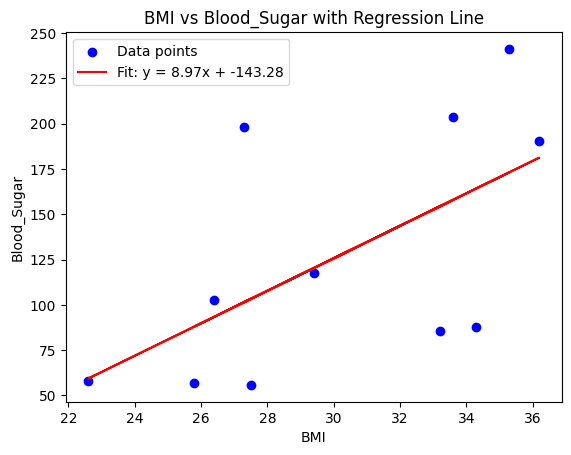

In [20]:

make_xy_scatter_plot(df, 'BMI', 'Blood_Sugar')

Filtered dataset size: 12 subjects



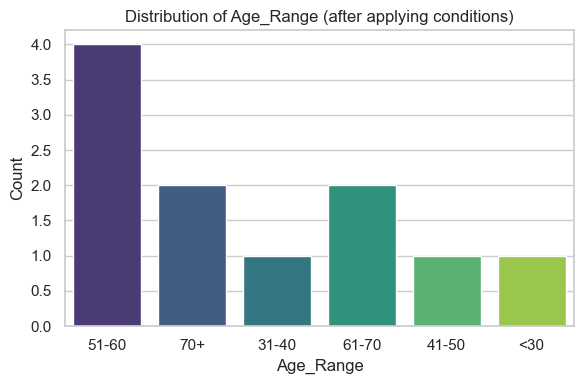

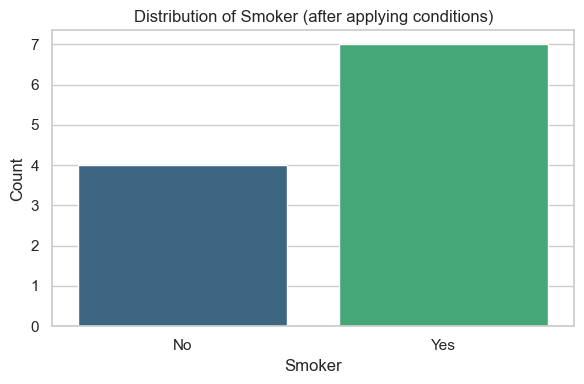

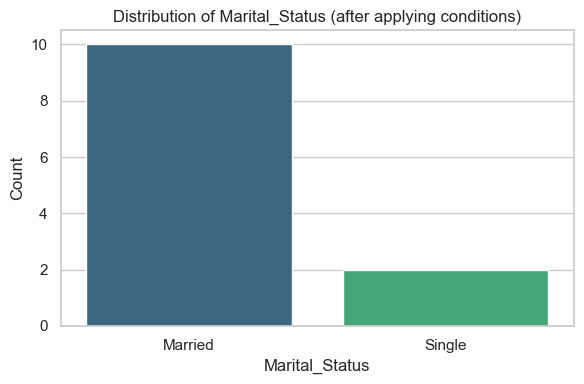

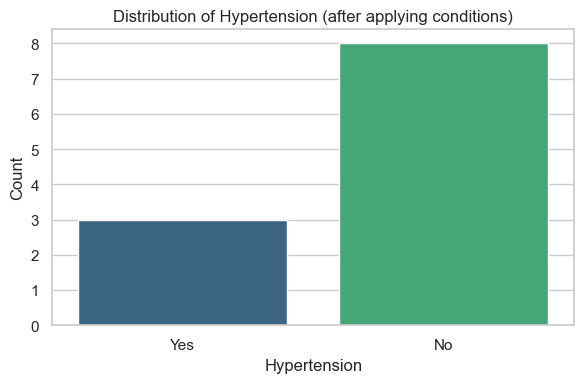

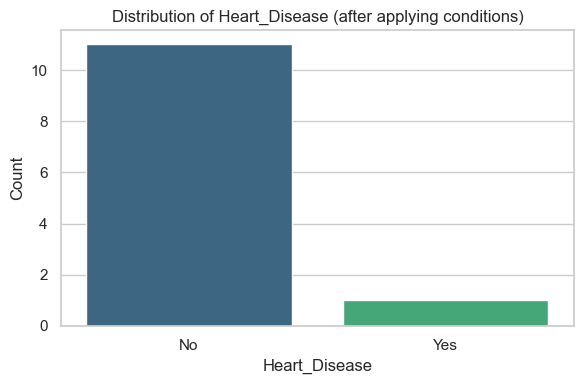

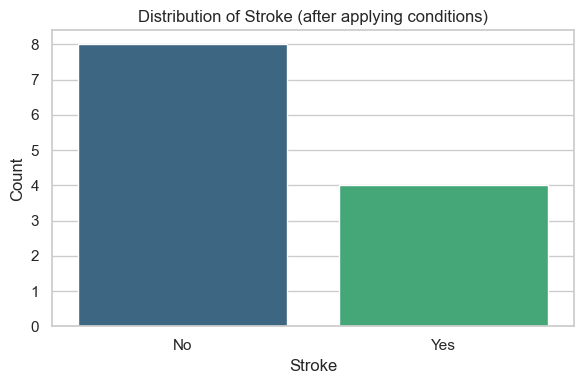

In [5]:
# show analysis result from the entire original dataset (without any condition)
analyze_data({})

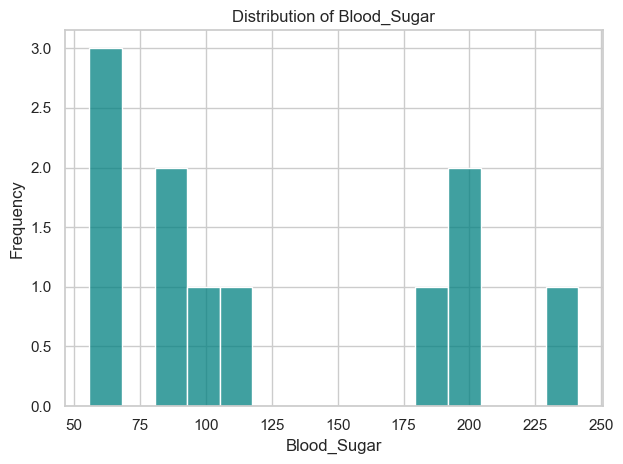

In [6]:
feature = 'Blood_Sugar'
make_histogram(df, feature, bins=15)

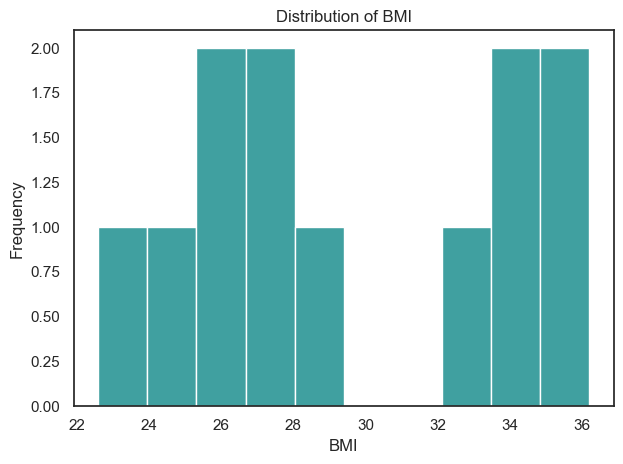

In [154]:
feature = 'BMI'
make_histogram(df, feature, bins=10)

<br>
<br>
<div dir="rtl">
  בנוסף, נבחין כי יש 4 נבדקים שאחד הפיצרים שלהם חסר. נתמודד איתם אחד-אחד

In [15]:
# show all rows in dataset with NaN values
df[df.isna().any(axis=1)]

,Subject_ID,Age_Range,Smoker,Marital_Status,Hypertension,Blood_Sugar,BMI,Heart_Disease,Stroke
3,4,70+,Yes,Married,NaN,198.21,27.3,No,Yes
6,7,NaN,Yes,Married,No,190.50,36.2,No,Yes
7,8,51-60,NaN,Married,Yes,56.64,25.8,No,No
9,10,41-50,No,Married,No,NaN,25.1,No,No


<br>
<br>
<div dir="rtl">
    
### מקרה ראשון - סטטוס יתר לחץ הדם בקרב נבדק מספר 4

<br>
<br>
<div dir="rtl">
 .נבחין כי לנבדק מספר 4 חסר הערך הבינרי אודות שאלת יתר לחץ הדם
<br><br>
מדובר בנבדק בן 70+. יש רק 2 נבדקים (נבדקים מספר 2 ו-4) שנצאים בטווח גילאים זה. מהשוואה בין הפיצרים של נבדקים אלו עולה כי ברוב הקטגוריות הם די דומים - למעשה מלבד 2 קטגוריות: 

1. לנבדק 2 יש מחלה לבבית בניגוד לנבדק 4 שאין לו מחלה לבבית
2. רמת הסוכר של נבדק 4 גבוה בכמעט פי 2.5 (242.45%) ביחס לנבדק 2

ייתכן שלאחד (אם לא לשני) ההבדלים הללו יש השפעה ניכרת על שאלת יתר לחץ הדם, לכן נבדוק האם יש מתאם חזק מספיק בין פיצרים אלו ובין הימצאות יתר לחץ דם בנבדק

In [54]:
df.query("Age_Range == '70+'")

,Subject_ID,Age_Range,Smoker,Marital_Status,Hypertension,Blood_Sugar,BMI,Heart_Disease,Stroke
1,2,70+,Yes,Married,No,57.88,22.6,Yes,Yes
3,4,70+,Yes,Married,NaN,198.21,27.3,No,Yes


<br>
<br>
<div dir="rtl">
אכן, נמצא כן יש קשר מובהק. מבדיקה של כל הנבדקים שלחץ הדם שלהם גבוה מ-120 וגם אין להם מחלה לבבית, נמצא שהם אינם סובלים מיתר לחץ דם.
<br>
כמו כן, התבוננות על יתר הפיצרים מראה כי או שהם כנראה אינם תלויים, כמו ההימצאות של שבץ או היותו של הנבדק מעשן, או שכמעט כל הפיצרים, מלבד ה BMI, הם בגדול די קרובים.
<br>
כולם נשואים וללא מחלה לבבית, מעל גיל 61 ורמת סוכר מעל 190.
<br>
לאור נתונים אלו, מסתמן כי התיקון 
    Hypertension = No
עבור נבדק מספר 4 הוא תיקון אפשרי

In [55]:
df.query("(Heart_Disease == 'No') & (Blood_Sugar > 120)")

,Subject_ID,Age_Range,Smoker,Marital_Status,Hypertension,Blood_Sugar,BMI,Heart_Disease,Stroke
3,4,70+,Yes,Married,NaN,198.21,27.3,No,Yes
6,7,NaN,Yes,Married,No,190.50,36.2,No,Yes
8,9,61-70,No,Married,No,203.44,33.6,No,No
10,11,61-70,Yes,Married,No,241.30,35.3,No,Yes


<br>
<br>
<div dir="rtl">
כדי להיות בטוח יותר בתיקון המוצא, החלטתי לוודא שאין מתאם משמעותי מספיק בין BMI ליתר לחץ דם, כלומר שעלייה או ירידה בערך ה BMI בקרב נבדקים עם מאפיינים דומים לאלו שופיעים למעלה לא מובילה בהכרח לעלייה או לירידה בסבירות לסבול מיתר לחץ דם.
<br><br>
אכן, מסתמן כי אין קשר - אזי התיקון המוצא התקבל

In [66]:
df.query("(Marital_Status == 'Married') & (Heart_Disease == 'No')").sort_values(by = "BMI")

,Subject_ID,Age_Range,Smoker,Marital_Status,Hypertension,Blood_Sugar,BMI,Heart_Disease,Stroke
9,10,41-50,No,Married,No,NaN,25.1,No,No
7,8,51-60,NaN,Married,Yes,56.64,25.8,No,No
11,12,<30,Yes,Married,No,102.64,26.4,No,No
3,4,70+,Yes,Married,NaN,198.21,27.3,No,Yes
5,6,51-60,Yes,Married,No,117.52,29.4,No,No
8,9,61-70,No,Married,No,203.44,33.6,No,No
0,1,51-60,No,Married,Yes,87.56,34.3,No,No
10,11,61-70,Yes,Married,No,241.30,35.3,No,Yes
6,7,NaN,Yes,Married,No,190.50,36.2,No,Yes


<br>
<br>
<div dir="rtl">
    
### מקרה שני - השלמת גילו של נבדק מספר 7

In [37]:
fixed_df.query("Subject_ID == 7")

,Subject_ID,Age_Range,Smoker,Marital_Status,Hypertension,Blood_Sugar,BMI,Heart_Disease,Stroke
6,7,NaN,Yes,Married,No,190.5,36.2,No,Yes


<br>
<br>
<div dir="rtl">
מדובר באדם מעשן ונשוי, שרמת הסוכר בדם שלו גבוהה מאוד, מעל 190. זאת בהלימה להיותו שמן (obesity class 2 מוגדרת כBMI בין 35 ל-40)
    <br><br>
כמו כן, הוא חווה שבץ, אך אינו סובל מיתר לחץ דם וללא מחלה לבבית

In [34]:
fixed_df.query("(Smoker == 'Yes') & (Blood_Sugar >= 120)")

,Subject_ID,Age_Range,Smoker,Marital_Status,Hypertension,Blood_Sugar,BMI,Heart_Disease,Stroke
3,4,70+,Yes,Married,No,198.21,27.3,No,Yes
6,7,NaN,Yes,Married,No,190.50,36.2,No,Yes
10,11,61-70,Yes,Married,No,241.30,35.3,No,Yes


<br>
<br>
<div dir="rtl">
על פי בסיס הנתונים המתוקן, יש בדיוק 3 נבדקים, כולל נבדק 7, עם נתונים דומים. ביניהם נבדק מספר 4 שייתכן כי ערך ה BMI שלו שגוי. 
<br>
נבדקים 4 ו-11 הם מעל גיל 60, לכן תיקון הגיל של נבדק 7 להיות 61-70 נראה סביר. ייתכן שגם ההשמה של 70+ היא בחירה הגיונית, אולם תחת הסרת תנאי העשיון בשאילתא (כלומר רק ממעבר על כל הנבדקים שרמת הסוכר שלהם מעל 120) נראה שהבחירה הראשונה הגיונית יותר על פי שיטת ההכרעה על פי "הרוב קובע "

In [36]:
fixed_df.query("Blood_Sugar >= 120")

,Subject_ID,Age_Range,Smoker,Marital_Status,Hypertension,Blood_Sugar,BMI,Heart_Disease,Stroke
3,4,70+,Yes,Married,No,198.21,27.3,No,Yes
6,7,NaN,Yes,Married,No,190.50,36.2,No,Yes
8,9,61-70,No,Married,No,203.44,33.6,No,No
10,11,61-70,Yes,Married,No,241.30,35.3,No,Yes


<br>
<br>
<div dir="rtl">
    
### מקרה שלישי - סטטוס העישון של נבדר מספר 8 

In [42]:
fixed_df.query("Subject_ID == 8")

,Subject_ID,Age_Range,Smoker,Marital_Status,Hypertension,Blood_Sugar,BMI,Heart_Disease,Stroke
7,8,51-60,NaN,Married,Yes,56.64,25.8,No,No


<br>
<br>
<div dir="rtl">
מסודר באדם בטווח הגילאים 51-60, נשוי עם יתר לחץ דם. ערך ה BMI שלו יחסית תקין, 25.8, אולם רמת הסוכר שלו נמוכה באופן קיצוני, אני חושב שגם מבלי להיות רופא, מדובר ברמת סוכר מסכנת חיים. 
<br>
כמו כן, אין לו מחלה לבבית והוא אינו עבר שבץ
<br><br>
על פי מפת החום הכללית, אוכלוסיית המעשנים ולא מעשנים בקרב הגילאים 51-61 היא מאוזנת. אולם, יש מתאם חיובי חזק בין קטגוריית העישון ובין:

1. קיום שבץ
2. קיום של מחלה לבבית
   
<div dir="rtl">
<br><br>
לחתח נתונים זה נוסיף את התנאי של BMI נמוך מ30 , כלומר כל הנבדקים שאינם סובלים מהשמנת יתר (להבדיל מעודף משקל)
<br>
תחת חתח זה קיבלנו מספיק נבדקים, 5 במספר, ביניהם 3 מעשנים ורק 1 לא מעשן, לכן התיקון שבו נבדק מספר 8 כן מעשן נראת הכי סבירה
<div dir="rtl">

In [155]:
fixed_df.query("(Stroke == 'No') & (Heart_Disease == 'No') & (BMI < 30)")

,Subject_ID,Age_Range,Smoker,Marital_Status,Hypertension,Blood_Sugar,BMI,Heart_Disease,Stroke
4,5,51-60,Yes,Single,Yes,55.78,27.5,No,No
5,6,51-60,Yes,Married,No,117.52,29.4,No,No
7,8,51-60,NaN,Married,Yes,56.64,25.8,No,No
9,10,41-50,No,Married,No,NaN,25.1,No,No
11,12,<30,Yes,Married,No,102.64,26.4,No,No


<br>
<br>
<div dir="rtl">
    
### מקרה רביעי - רמת הסוכר בדם של נבדק 10

In [158]:
fixed_df.query("Subject_ID == 10")

,Subject_ID,Age_Range,Smoker,Marital_Status,Hypertension,Blood_Sugar,BMI,Heart_Disease,Stroke
9,10,41-50,No,Married,No,NaN,25.1,No,No


<br>
<br>
<div dir="rtl">
מדובר בנבדק שגילו בין 41-50, לא מעשן, ללא מחלה לבבית, ללא יתר לחץ דם ואינו חווה שבץ. BMI תקין. סטטוס משפחתי נשוי
<br><br>
על פי כל הנתונים הרפואים נראה כי מסובר בסך הכל בבן אדם בריא. לכן סביר שהדבר יבוא לידי ביטוי גם ברמת סוכר תקינה    
<br><br>
אין מספיק נבדקים עם נתוני בריאות טובים כמו של נבדק 10. הנבדק הקרוב לו ביותר הוא נבדק מספר 3, וזאת למרות של על פי ה BMI שלו הוא סובל מהשמנה, וכן הוא בקבוצת גיל שונה לחלוטין
<br><br>
 לכן, התיקון הסביר ביותר הוא לשים באופן שרירותי ערך של רמת סוכר בדם המשקפת אדם בריא שלא מעשן וללא מחלות לבביות מעל גיל 50. נראה לי שהערך 110 היא סבירה, בדיוק במרכז הטווח התקין על פי הנחת היסוד בין 80 ל -140.

In [175]:
fixed_df.query("(Blood_Sugar >= 80) & (Blood_Sugar <= 140) & (Hypertension == 'No') & (Smoker == 'No')")

,Subject_ID,Age_Range,Smoker,Marital_Status,Hypertension,Blood_Sugar,BMI,Heart_Disease,Stroke
2,3,31-40,No,Single,No,85.37,33.2,No,No


<br>
<br>
<div dir="rtl">

### דיון בנוגע לערכים אנומליים

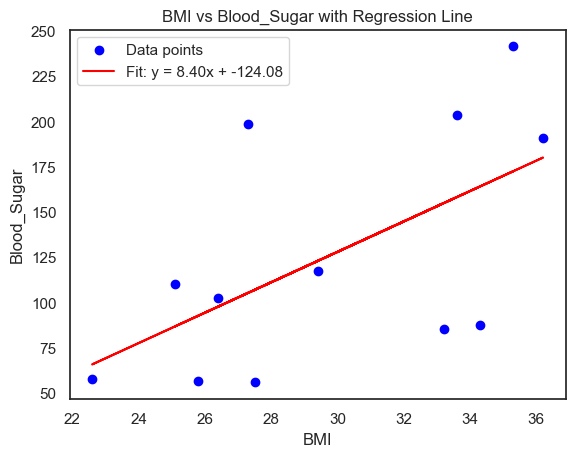

In [180]:
make_xy_scatter_plot(fixed_df, 'BMI', 'Blood_Sugar')

<br>
<br>
<div dir="rtl">
לאחר השלמת רמת הסוכר בדם של נבדק 10, הליניאריות של הקשר BMI vs Blood_Sugar ברורה יותר
לכן נתחיל לדון בפתרון האנומליות, ספק שגיאות, שעולים מגרף זה. 
יש 3 נקודות אנומליות השייכות לנבדקים 1,3 ו-4. בטרם נמהר לבצע תיקון, נזכור כי ייתכן שערכים אנומלים אלו הם סיבה או תוצאה של בעיה בריאותית כלשהי, כלומר אכן יש הלימה בין BMI גבוה לרמת סוכר בדם גבוהה, אולם ייתכן שהנבדק חתף שבץ כתוצאה מעישון יתר, דבר שגרר הורדה במשקל.
<br><br>
לכן, נראה לי הכי הגיוני לבצע תיקון רק עבור שורות של נבדקים בריאים, כלומר רק עבור נבדק מספר 3 שכל הנתונים הבריאותיים שלו אינם בהלימה עם הBMI שלו, ולכן לדעתי זהו הערך השגוי שיש לתקן

In [182]:
fixed_df.query("Subject_ID in (1, 3, 4)").sort_values(by = 'Blood_Sugar')

,Subject_ID,Age_Range,Smoker,Marital_Status,Hypertension,Blood_Sugar,BMI,Heart_Disease,Stroke
2,3,31-40,No,Single,No,85.37,33.2,No,No
0,1,51-60,No,Married,Yes,87.56,34.3,No,No
3,4,70+,Yes,Married,No,198.21,27.3,No,Yes


<br>
<br>
<div dir="rtl">
בדומה לתיקון שנעשה עבור נבדק 10, מכיוון שבסיס נתונים זה לא מכיל מספיק מידע על נבדקים בריאים, לא ניתן למצע את הנתון החסר על סמך בסיס נתונים זה, לכן נעדיף לתקן עם ערך שרירותי אך הגיוני. נבחר ב BMI = 22.25, שזה בדיוק ערך האמצע בטווח הערכים התקין שהנחתי בהתחלה עבור BMI בין 19.5 ל -25.

<br>
<br>
<div dir="rtl">

### דיסקרטיזציה

In [9]:
fixed_df

,Subject_ID,Age_Range,Smoker,Marital_Status,Hypertension,Blood_Sugar,BMI,Heart_Disease,Stroke
0,1,51-60,No,Married,Yes,87.56,34.30,No,No
1,2,70+,Yes,Married,No,57.88,22.60,Yes,Yes
2,3,31-40,No,Single,No,85.37,22.25,No,No
3,4,70+,Yes,Married,No,198.21,27.30,No,Yes
4,5,51-60,Yes,Single,Yes,55.78,27.50,No,No
5,6,51-60,Yes,Married,No,117.52,29.40,No,No
6,7,61-70,Yes,Married,No,190.50,36.20,No,Yes
7,8,51-60,Yes,Married,Yes,56.64,25.80,No,No
8,9,61-70,No,Married,No,203.44,33.60,No,No
9,10,41-50,No,Married,No,110.00,25.10,No,No


<br>
<br>
<div dir="rtl">
נבצע דיסקרטיזציה על הפיצרים:

1. BMI - נבצע סיווג בינארי שייוצג על ידי המספרים 25 ו-33, שאלו (בעיגול כלפי מעלה) הערכים הממוצעים סביב BMI תקין ולא תקין
2. רמת סוכר - נסווג בינארית לתקין/לא-תקין על פי האופן שהגדרנו בהתחלה


<br>
<div dir="rtl">
מראש אציין כי תחת התיקונים שביצעתי, לא מצאתי דיסקרטיזציה טובה עבור גיל הנבדקים. מדובר בקטגוריה בעייתית שיש לה התאמה מידית בין גיל לשבץ. מכיוון שאנטרופיה נוטה להעריך מדי קטגוריות עם הרבה attributes הדבר מוביל לכך שקטגורית הגיל נבחרת בשורש עץ ההחלטה, ומשם לא הצלחתי לבנות עץ עם 2 רמות נוספות כנדרש. לכן החלטתי לוותר לגמרי על קטגורית הגיל במהלך בניית עץ ההחלטה, דבר שמיד השתלם כי הצלתחתי להגיע בהיעדרה לסיווג מושלם.


<br>
<br>
<div dir="rtl">
נחלק את הBMI ל-2 חלקים שווים בגודלם:

1. BMI >= 27.5
2. BMI < 27.5

<br>
<div dir="rtl">
נבחר כנציג של כל חלוקה את הממוצע (מעוגל כלפי מעלה) של כל ערכי ה BMI שחברים באותה קבוצה

In [52]:
print(round(fixed_df.query("BMI < 27.5")['BMI'].mean()))
print(round(fixed_df.query("BMI >= 27.5")['BMI'].mean()))

25
33


In [12]:
fixed_df['BMIGroup'] = fixed_df['BMI'].apply(lambda x: 25 if x < 27.5 else 33)

In [55]:
fixed_df.sort_values(by='Blood_Sugar')

,Subject_ID,Smoker,Marital_Status,Hypertension,Blood_Sugar,BMI,Heart_Disease,Stroke,New_Age_Range,BMI_Range
4,5,Yes,Single,Yes,55.78,27.50,No,No,51-60,33
7,8,Yes,Married,Yes,56.64,25.80,No,No,51-60,25
1,2,Yes,Married,No,57.88,22.60,Yes,Yes,61+,25
2,3,No,Single,No,85.37,22.25,No,No,0-50,25
0,1,No,Married,Yes,87.56,34.30,No,No,51-60,33
11,12,Yes,Married,No,102.64,26.40,No,No,0-50,25
9,10,No,Married,No,110.00,25.10,No,No,0-50,25
5,6,Yes,Married,No,117.52,29.40,No,No,51-60,33
6,7,Yes,Married,No,190.50,36.20,No,Yes,61+,33
3,4,Yes,Married,No,198.21,27.30,No,Yes,61+,25


<br>
<br>
<div dir="rtl">
נבצע דיקרטיזציה של רמת הסוכר ל-2 קטגוריות:

1. רמת סוכר לא תקינה  (BS < 80 || BS > 140)
2. רמת סוכר תקינה (80 <= BS <= 140)


In [10]:
fixed_df['NormalBSL'] = fixed_df['Blood_Sugar'].apply(lambda x: 'Yes' if (80 <= x <= 140) else 'No')

In [13]:
fixed_df.sort_values(by = 'NormalBSL')

,Subject_ID,Age_Range,Smoker,Marital_Status,Hypertension,Blood_Sugar,BMI,Heart_Disease,Stroke,NormalBSL,BMIGroup
1,2,70+,Yes,Married,No,57.88,22.60,Yes,Yes,No,25
3,4,70+,Yes,Married,No,198.21,27.30,No,Yes,No,25
4,5,51-60,Yes,Single,Yes,55.78,27.50,No,No,No,33
6,7,61-70,Yes,Married,No,190.50,36.20,No,Yes,No,33
7,8,51-60,Yes,Married,Yes,56.64,25.80,No,No,No,25
8,9,61-70,No,Married,No,203.44,33.60,No,No,No,33
10,11,61-70,Yes,Married,No,241.30,35.30,No,Yes,No,33
0,1,51-60,No,Married,Yes,87.56,34.30,No,No,Yes,33
2,3,31-40,No,Single,No,85.37,22.25,No,No,Yes,25
5,6,51-60,Yes,Married,No,117.52,29.40,No,No,Yes,33


<br>
<br>
<div dir="rtl">
לסיום, ניפתר מעמודות מיותרות 
<br>
    את הגיל בחרתי כן להשאיר, למרות שתכנית אולי אני כן צריך להוריד אותו לצורך התרגיל, רק כדי להדגיש שמובר במידע חשוב (אולי מדי) שראוי שיימצא בבסיס הנתונים, הגם שאני מתעלם ממנו בבניית עץ ההחלטה

In [14]:
# at the end, get rid of old BMI and Blood_Sugar columns
fixed_df = fixed_df.drop('Blood_Sugar', axis=1)
fixed_df = fixed_df.drop('BMI', axis=1)

<br>
<br>
<div dir="rtl">

### שלב הסיום - הצגת בסיס נתונים מטויב

In [15]:
fixed_df

,Subject_ID,Age_Range,Smoker,Marital_Status,Hypertension,Heart_Disease,Stroke,NormalBSL,BMIGroup
0,1,51-60,No,Married,Yes,No,No,Yes,33
1,2,70+,Yes,Married,No,Yes,Yes,No,25
2,3,31-40,No,Single,No,No,No,Yes,25
3,4,70+,Yes,Married,No,No,Yes,No,25
4,5,51-60,Yes,Single,Yes,No,No,No,33
5,6,51-60,Yes,Married,No,No,No,Yes,33
6,7,61-70,Yes,Married,No,No,Yes,No,33
7,8,51-60,Yes,Married,Yes,No,No,No,25
8,9,61-70,No,Married,No,No,No,No,33
9,10,41-50,No,Married,No,No,No,Yes,25


<br><br>
<div dir="rtl">
    
### **שאלה 2**

    סעיף א - יש לבנות עץ החלטה חלקי הכולל רמת שורש ושתי רמות נוספות עבור בסיס הנתונים המתוקן

<br><br>
<div dir="rtl">
להלן פירוט חישובי האנטרופיה (בתקווה שאין לי שגיאות חישוב ...)

#### Entropy calculation - Level 0

$$
\begin{aligned}
& Info(Stroke) = (-1) \cdot [log_2P\{Stroke=Yes\} \cdot P\{Stroke=Yes\} + log_2P\{Stroke=No\} \cdot P\{Stroke=No\}] \\
&= (-1) \cdot [log_2(\frac{4}{12}) \cdot (\frac{4}{12}) + log_2(\frac{7}{12}) \cdot (\frac{7}{12})] \\
&= 0.982
\end{aligned}
$$

| $v_j$ = Smoker | $P(Smoker = v_j)$ | $Info(Stroke \\| Smoker = v_j)$ |
|:--------------:|:-----------------:|:----------------------------:|
|       Yes      |       $\frac{8}{12}$             |           $ \\| 2 \cdot \frac{4}{8} \cdot log_2(\frac{4}{8}) \\| = 1 $                    |
|       No       |          $\frac{4}{12}$          |            0 (no non-smoker have a Stroke)                    |

<br>

&rarr; $ Info_{Smoker}(Stroke) = \frac{8}{12} = \frac{2}{3} \approx 0.667   $
<br>
&rarr; $ Gain(Smoker) \approx 0.982 - 0.667 \approx 0.315 $

---

| $v_j$ = Martinal_Status | $P(Martinal_Status = v_j)$ | $Info(Stroke \\| Martinal_Status = v_j)$ |
|:--------------:|:-----------------:|:----------------------------:|
|       Married      |       $\frac{10}{12}$             |           $ \\| 0.4 \cdot log_2(0.4) + 0.6 \cdot log_2(0.6) \\| \approx 0.971 $                    |
|       Single      |          $\frac{2}{12}$          |            0 (no signle have a Stroke)                    |

<br>

&rarr; $ Info_{Martinal_Status}(Stroke) = \frac{10}{12} \dot 0.971  \approx 0.809   $
<br>
&rarr; $ Gain(Martinal_Status) \approx 0.982 - 0.809 \approx 0.173 $

---

| $v_j$ = Hypertension | $P(Martinal_Status = v_j)$ | $Info(Stroke \\| Hypertension = v_j)$ |
|:--------------:|:-----------------:|:----------------------------:|
|       Yes      |       $\frac{3}{12}$             |            0 (no one with Hypertension have a Stroke)                    |
|       No      |          $\frac{9}{12}$          |            $ \\| \frac{4}{9} \cdot log_2(\frac{4}{9}) + \frac{5}{9} \cdot log_2(\frac{5}{9}) \\| \approx 0.991 $                 |

<br>

&rarr; $ Info_{Hypertension}(Stroke) = \frac{9}{12} \dot 0.991 \approx 0.743   $
<br>
&rarr; $ Gain(Hypertension) \approx 0.982 - 0.743 \approx 0.239 $

---

| $v_j$ = NormalBSL | $P(NormalBSL = v_j)$ | $Info(Stroke \\| NormalBSL = v_j)$ |
|:--------------:|:-----------------:|:----------------------------:|
|       $ 80 < Sugar < 140 $       |       $\frac{5}{12}$             |            0 (no one with NormalBSL have a Stroke)                    |
|       otherwide      |          $\frac{7}{12}$          |            $ \\| \frac{4}{7} \cdot log_2(\frac{4}{7}) + \frac{3}{7} \cdot log_2(\frac{3}{7}) \\| \approx 0.985 $                 |

<br>

&rarr; $ Info_{NormalBSL}(Stroke) = \frac{7}{12} \dot 0.985 \approx 0.574  $
<br>
&rarr; $ Gain(NormalBSL) \approx 0.982 - 0.574 \approx 0.408 $

---

| $v_j$ = BMIGroup | $P(BMIGroup = v_j)$ | $Info(Stroke \\| BMIGroup = v_j)$ |
|:--------------:|:-----------------:|:----------------------------:|
|      25      |       $\frac{7}{12}$             |         $ \\| \frac{2}{7} \cdot log_2(\frac{2}{7}) + \frac{5}{7} \cdot log_2(\frac{5}{7}) \\| \approx 0.485 $                        |
|       33      |          $\frac{5}{12}$          |            $ \\| \frac{2}{5} \cdot log_2(\frac{2}{5}) + \frac{3}{5} \cdot log_2(\frac{3}{5}) \\| \approx 0.971 $                 |

<br>

&rarr; $ Info_{BMIGroup}(Stroke) = \frac{7}{12} \dot 0.485  \frac{5}{12} \dot 0.971 + \approx 0.6875  $
<br>
&rarr; $ Gain(BMIGroup) = 0.982 - 0.6875 = 0.2945 $


---

Heart_Disease


| $v_j$ = Heart_Disease | $P(Heart_Disease = v_j)$ | $Info(Stroke \\| Heart_Disease = v_j)$ |
|:--------------:|:-----------------:|:----------------------------:|
|      Yes      |       $\frac{1}{12}$             |         0 (every one with Heart_Disease have a Stroke)                       |
|       No      |          $\frac{11}{12}$          |            $ \\| \frac{4}{11} \cdot log_2(\frac{4}{11}) + \frac{7}{11} \cdot log_2(\frac{7}{11}) \\| \approx 0.946 $                 |

<br>

&rarr; $ Info_{Heart_Disease}(Stroke) \approx \frac{11}{12} \dot 0.946 \approx 0.867  $
<br>
&rarr; $ Gain(Heart_Disease) = 0.982 - 0.867 = 0.115 $

#### Enrtopy Root Level Summary

|     Feature     | Gain |
|:---------------:|:----:|
|      Smoker     |    0.315  |
| Martinal_Status |   0.173   |
| Hypertension  |    0.239  |
| NormalBSL       |    0.408  |
| BMIGroup        |   0.2945   |
| Heart_Disease  |   0.115   |

<br> 

Therefore, the chosen root feature will be **NormalBSL**


In [23]:
# for NormalBSL == 'Yes' ==> we resolve a 'No' leaf (no one with NormalBSL, Blood_Sugar <= 27.5,  had a Stroke) 
level_1 = fixed_df.query("NormalBSL == 'No'")

In [24]:
level_1

,Subject_ID,Age_Range,Smoker,Marital_Status,Hypertension,Heart_Disease,Stroke,NormalBSL,BMIGroup
1,2,70+,Yes,Married,No,Yes,Yes,No,25
3,4,70+,Yes,Married,No,No,Yes,No,25
4,5,51-60,Yes,Single,Yes,No,No,No,33
6,7,61-70,Yes,Married,No,No,Yes,No,33
7,8,51-60,Yes,Married,Yes,No,No,No,25
8,9,61-70,No,Married,No,No,No,No,33
10,11,61-70,Yes,Married,No,No,Yes,No,33


#### Entropy calculation - Level 1

$$
\begin{aligned}
& Info(Stroke) = (-1) \cdot [log_2P\{Stroke=Yes\} \cdot P\{Stroke=Yes\} + log_2P\{Stroke=No\} \cdot P\{Stroke=No\}] \\
&= (-1) \cdot [log_2(\frac{4}{7}) \cdot (\frac{4}{7}) + log_2(\frac{3}{7}) \cdot (\frac{3}{7})] \\
&= 0.985
\end{aligned}
$$

| $v_j$ = Smoker | $P(Smoker = v_j)$ | $Info(Stroke \\| Smoker = v_j)$ |
|:--------------:|:-----------------:|:----------------------------:|
|       Yes      |           $\frac{6}{7}$          |           $ \\|  \frac{2}{6} \cdot log_2(\frac{2}{6}) +  \frac{4}{6} \cdot log_2(\frac{4}{6}) \\| = 0.918 $                    |
|       No       |           $\frac{1}{7}$         |            0 (no non-smoker have a Stroke)                    |

<br>

&rarr; $ Info_{Smoker}(Stroke) = \frac{6}{7} \cdot 0.918 \approx 0.786   $
<br>
&rarr; $ Gain(Smoker) \approx 0.985 - 0.786 \approx 0.199 $

---


| $v_j$ = Martinal_Status | $P(Martinal_Status = v_j)$ | $Info(Stroke \\| Martinal_Status = v_j)$ |
|:--------------:|:-----------------:|:----------------------------:|
|       Married      |       $\frac{6}{7}$             |            $ \\|  \frac{2}{6} \cdot log_2(\frac{2}{6}) +  \frac{4}{6} \cdot log_2(\frac{4}{6}) \\| = 0.918 $                   |
|       Single      |          $\frac{1}{7}$          |            0 (no signle have a Stroke)                    |

<br>

&rarr; $ Info_{Martinal_Status}(Stroke) = \frac{6}{7} \cdot 0.918 \approx 0.786   $
<br>
&rarr; $ Gain(Martinal_Status) \approx 0.985 - 0.786 \approx 0.199 $

---

| $v_j$ = Hypertension | $P(Martinal_Status = v_j)$ | $Info(Stroke \\| Hypertension = v_j)$ |
|:--------------:|:-----------------:|:----------------------------:|
|       Yes      |       $\frac{2}{7}$             |            0 (no one with Hypertension have a Stroke)                    |
|       No      |          $\frac{5}{7}$          |            $ \\| \frac{4}{5} \cdot log_2(\frac{4}{5}) + \frac{1}{5} \cdot log_2(\frac{1}{5}) \\| \approx 0.722 $                 |

<br>

&rarr; $ Info_{Hypertension}(Stroke) = \frac{5}{7} \dot 0.722 \approx 0.516   $
<br>
&rarr; $ Gain(Hypertension) \approx 0.985 - 0.722 \approx 0.469 $

---

| $v_j$ = BMIGroup | $P(BMIGroup = v_j)$ | $Info(Stroke \\| BMIGroup = v_j)$ |
|:--------------:|:-----------------:|:----------------------------:|
|      25      |       $\frac{4}{7}$             |         1      (50-50)                  |
|       33      |          $\frac{3}{7}$          |            $ \\| \frac{2}{3} \cdot log_2(\frac{2}{3}) + \frac{1}{3} \cdot log_2(\frac{1}{3}) \\| \approx 0.918 $                 |

<br>

&rarr; $ Info_{BMIGroup}(Stroke) = \frac{4}{7} + \frac{3}{7} \cdot 0.918  \approx 0.965  $
<br>
&rarr; $ Gain(BMIGroup) = 0.985 - 0.965 = 0.02 $


---

Heart_Disease


| $v_j$ = Heart_Disease | $P(Heart_Disease = v_j)$ | $Info(Stroke \\| Heart_Disease = v_j)$ |
|:--------------:|:-----------------:|:----------------------------:|
|      Yes      |       $\frac{1}{7}$             |         0 (every one with Heart_Disease have a Stroke)                       |
|       No      |          $\frac{6}{7}$          |            1       (50-50)       |

<br>

&rarr; $ Info_{Heart_Disease}(Stroke) = \frac{6}{7} $
<br>
&rarr; $ Gain(Heart_Disease) = 0.985 - 0.867 \approx 0.128 $



#### Enrtopy Level 1 Summary

|     Feature     | Gain |
|:---------------:|:----:|
|      Smoker     |    0.199  |
| Martinal_Status |   0.199   |
| Hypertension  |    0.469  |
| BMIGroup        |   0.02   |
| Heart_Disease  |   0.128   |

<br> 

Therefore, the chosen level 1 feature will be **Hypertension**

In [54]:
level_1.query("Hypertension == 'Yes'")

,Subject_ID,Age_Range,Smoker,Marital_Status,Hypertension,Blood_Sugar,BMI,Heart_Disease,Stroke
4,5,51-60,Yes,Single,Yes,55.78,27.5,No,No
7,8,51-60,Yes,Married,Yes,56.64,25.8,No,No


In [53]:
level_1.query("Hypertension == 'No'")

,Subject_ID,Age_Range,Smoker,Marital_Status,Hypertension,Blood_Sugar,BMI,Heart_Disease,Stroke
1,2,70+,Yes,Married,No,57.88,22.6,Yes,Yes
3,4,70+,Yes,Married,No,198.21,27.3,No,Yes
6,7,61-70,Yes,Married,No,190.50,36.2,No,Yes
8,9,61-70,No,Married,No,203.44,33.6,No,No
10,11,61-70,Yes,Married,No,241.30,35.3,No,Yes


In [26]:
level_2 = level_1.query("Hypertension == 'No'")

In [27]:
level_2

,Subject_ID,Age_Range,Smoker,Marital_Status,Hypertension,Heart_Disease,Stroke,NormalBSL,BMIGroup
1,2,70+,Yes,Married,No,Yes,Yes,No,25
3,4,70+,Yes,Married,No,No,Yes,No,25
6,7,61-70,Yes,Married,No,No,Yes,No,33
8,9,61-70,No,Married,No,No,No,No,33
10,11,61-70,Yes,Married,No,No,Yes,No,33


<br><br>
<div dir="rtl">
נשים לב שאין צורך לבצע חישובי אנטרופיה נוספים עבור הרמה השנייה וניתן לקחת את קטגוריית העישון שנמצאת במתאם מלא בינה ובין שבץ.
<br>
רוצה לומר, כל מי שמעשן יש לו שבץ, וכל מי שאינו מעשן אין לו שבץ

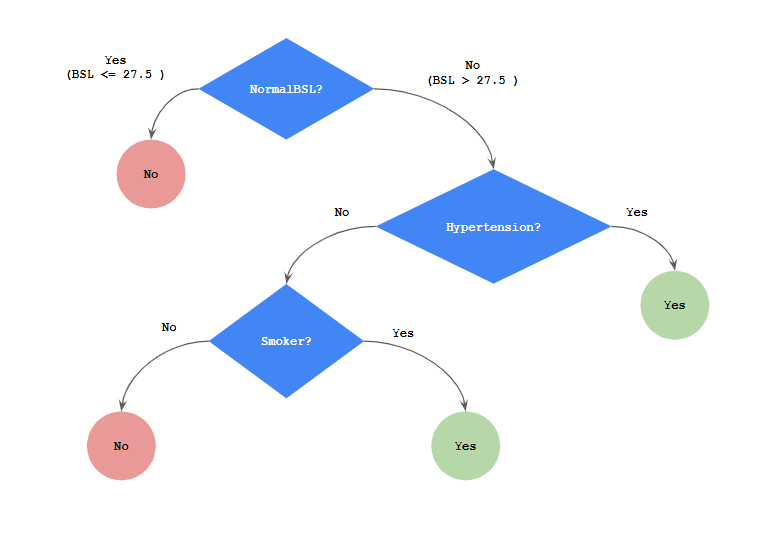

In [25]:
from IPython.display import Image
Image(filename='final_tree.png') 

<br><br>
<div dir="rtl">
    
### **שאלה 2**

    סעיף ב - איזה מבין התכונות ניתן להסיר ומדוע?

<br><br>
<div dir="rtl">
כפי שאמרתי קודם, (ומקווה שזה בסדר שלא הוספתי חישוב של קטגורית הגיל, כי גם ככה הממן הזה מכיל הרבה יותר מדי דברים מה שנראה לי הוא אמור להכיל...)  לא הייתה לי כל כך ברירה והייתי צריך להסיר את קטגורית הגיל. ייתכן ואף סביר שתחת תיקונים אחרים ניתן היה להגיע לסיווג מושלם, אולי עם מדד שונה, ללא צורך להסיר את עמודת הגיל. 
<br><br>
חוץ ממנה, ברור כי subjectId היא בסך הכל index column ולכן לא משתמשים בה במהלך החישוב, שאר הקטגוריות:

 - מצב משפחתי
 - קיום של מחלת לב
 - BMIGroup

לא נבחרו בשום ברמת השורש, הרמה הראשונה או הרמה השנייה של עץ ההחלטה על פי מדד האנטרופיה, ולכן ניתן להסיר אותם, אבל את זה ניתן לדעת רק בדיעבד.


<br><br>
<div dir="rtl">
על פי מדד האנטרופיה, ותחת הדיסקרטיזציה שבחרתי, לקטגוריות:

- רמת סוכר תקינה/לא-תקינה (NormalBSL)
- יתר לחץ דם (Hypertension)
- מעשן/לא-משען

<div dir="rtl">
הם החשובות ביותר, ולכן נבחרו בסדר זה כצמתים של עץ ההחלטה, על כן לא ניתן לוותר עליהם